In [ ]:
# 预测年收入是否超过 50k

import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import shap

# 1. 加载数据集
# X 包含特征，y 是标签（0: <=50k, 1: >50k）
X, y = shap.datasets.adult()

# 2. 识别类别特征
# 在 CatBoost 中，这是最关键的一步。
# 我们需要告诉模型，哪些列是类别（非连续数值）
# 剩下的所有列，模型都会默认把它们当作数值特征处理(e.g.Age,Capital Gain等)
cat_features = [
    'Workclass', 'Education-Num', 'Marital Status', 
    'Occupation', 'Relationship', 'Race', 'Sex', 'Country'
]

# 将这些列显式转为字符串（CatBoost 要求类别列不能是浮点数）
for col in cat_features:
    X[col] = X[col].astype(str)

# 3. 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 初始化 CatBoostClassifier
# 参数讲解：
# iterations: 树的棵数 (等同于 n_estimators)
# depth: 树的深度 (通常 6-10)
# learning_rate: 学习率
# loss_function: 损失函数，二分类通常用 Logloss
# verbose: 训练时每隔多少次打印一次进度
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    verbose=100,
    random_seed=42
)

# 5. 训练模型
# 核心点：必须传入 cat_features 参数
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test), # 传入验证集
    plot=True  # 开启实时训练看板（仅限 Jupyter 环境）
)

# 6. 预测与评估
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"\n准确率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC 评分: {roc_auc_score(y_test, y_prob):.4f}")

# 7. 查看 CatBoost 特征重要性
importances = model.get_feature_importance()
print("\n特征重要性:", dict(zip(X.columns, importances)))

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6027540	test: 0.6020069	best: 0.6020069 (0)	total: 184ms	remaining: 1m 31s
100:	learn: 0.2775414	test: 0.2820303	best: 0.2820303 (100)	total: 6.27s	remaining: 24.8s
200:	learn: 0.2623862	test: 0.2751449	best: 0.2750872 (198)	total: 12.2s	remaining: 18.2s
300:	learn: 0.2542344	test: 0.2739834	best: 0.2737795 (288)	total: 18.4s	remaining: 12.2s
400:	learn: 0.2468122	test: 0.2737583	best: 0.2733111 (347)	total: 26.5s	remaining: 6.54s
499:	learn: 0.2405131	test: 0.2741862	best: 0.2733111 (347)	total: 34.7s	remaining: 0us

bestTest = 0.273311072
bestIteration = 347

Shrink model to first 348 iterations.

准确率 (Accuracy): 0.8784
AUC 评分: 0.9305

特征重要性: {'Age': np.float64(12.44371775364903), 'Workclass': np.float64(3.0776983145924177), 'Education-Num': np.float64(8.017977994463), 'Marital Status': np.float64(6.897613665631889), 'Occupation': np.float64(7.78978141154248), 'Relationship': np.float64(21.433377314294493), 'Race': np.float64(1.3426930785781295), 'Sex': np.float64(2.20938

多分类问题的处理
最关键的是设置 loss_function

loss_function='MultiClass'：这是最常用的，对应Softmax。所有类别的概率之和严格等于 1
它假设每个样本只属于一个类别，类别是互斥的

loss_function='MultiClassOneVsAll'：将k分类转化为k个二分类问题
适用于类别之间不是完全互斥的情况。

如果你不指定 eval_metric，它默认就等于你的 loss_function（即 Logloss）

多分类比二分类复杂，损失函数不直观，故设置
eval_metric：建议设置为 'Accuracy'、'MultiClass' 或 'TotalF1'




标签：CatBoost 接受 0 到 N-1 的整数作为标签，也接受字符串形式的标签（它会自动处理）

Learning rate set to 0.08608
0:	learn: 0.6120731	total: 76.4ms	remaining: 38.1s
1:	learn: 0.5475775	total: 178ms	remaining: 44.2s
2:	learn: 0.4970487	total: 268ms	remaining: 44.4s
3:	learn: 0.4607870	total: 331ms	remaining: 41.1s
4:	learn: 0.4298543	total: 401ms	remaining: 39.7s
5:	learn: 0.4070330	total: 472ms	remaining: 38.8s
6:	learn: 0.3883636	total: 540ms	remaining: 38s
7:	learn: 0.3742121	total: 619ms	remaining: 38.1s
8:	learn: 0.3629875	total: 685ms	remaining: 37.4s
9:	learn: 0.3543695	total: 746ms	remaining: 36.6s
10:	learn: 0.3469363	total: 809ms	remaining: 36s
11:	learn: 0.3419472	total: 865ms	remaining: 35.2s
12:	learn: 0.3356424	total: 926ms	remaining: 34.7s
13:	learn: 0.3312849	total: 990ms	remaining: 34.4s
14:	learn: 0.3273482	total: 1.07s	remaining: 34.6s
15:	learn: 0.3239084	total: 1.19s	remaining: 36.1s
16:	learn: 0.3215675	total: 1.25s	remaining: 35.5s
17:	learn: 0.3197313	total: 1.31s	remaining: 35s
18:	learn: 0.3176451	total: 1.36s	remaining: 34.5s
19:	learn: 0.3151

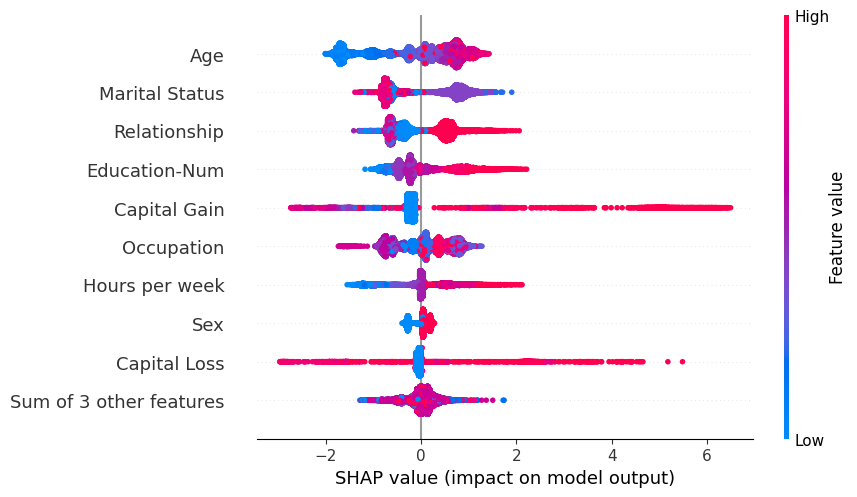

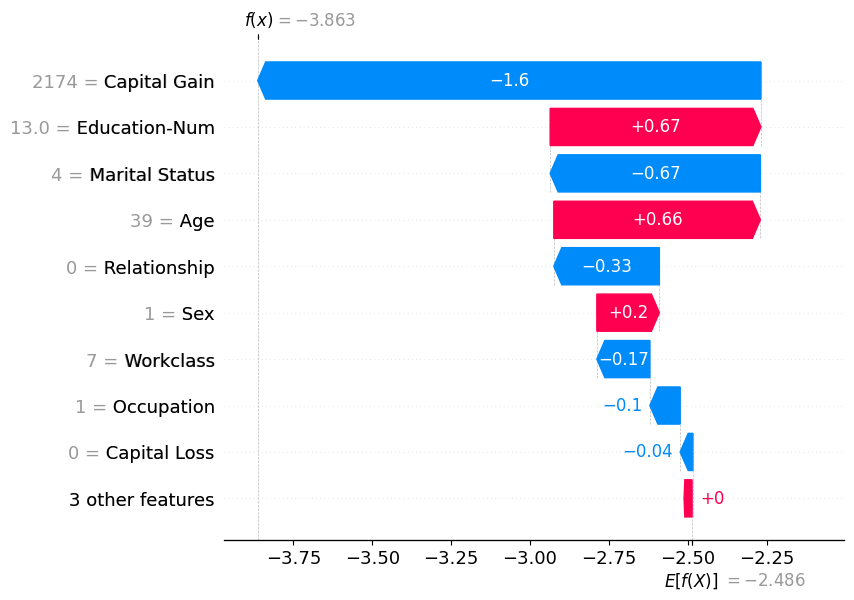

In [2]:
import shap
import catboost

# 1. 训练模型
model = catboost.CatBoostClassifier(iterations=500).fit(X, y, cat_features=cat_features)

# 2. 创建解释器 (TreeExplainer 专门支持 CatBoost)
explainer = shap.TreeExplainer(model)

# 3. 计算 SHAP 值
# 注意：对于 CatBoost，可以直接传入原始 DataFrame
shap_values = explainer(X)

# 4. 绘图（和之前学过的一模一样）
shap.plots.beeswarm(shap_values) # 蜂群图
shap.plots.waterfall(shap_values[0]) # 瀑布图（局部解释）